# Imputation of numerical columns

### Data Gathering and splitting

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('E:/Dataset/titanic_toy.csv')

In [3]:
df.isnull().mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [4]:
df.sample(2)

,Age,Fare,Family,Survived
387,36.0,13.0,0,1
538,NaN,14.5,0,0


In [5]:
x = df.iloc[:,:3]
y = df.iloc[:,-1]

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=34)

In [8]:
x_train.shape, x_test.shape

((712, 3), (179, 3))

In [9]:
x_train.isnull().mean()

Age       0.196629
Fare      0.046348
Family    0.000000
dtype: float64

## Filling value with <b>mean</b>, and <b>median</b>

### Using pandas

In [10]:
age_mean = x_train['Age'].mean()
age_median = x_train['Age'].median()

fare_mean = x_train['Fare'].mean()
fare_median = x_train['Fare'].median()

In [11]:
x_train['age_mean'] = x_train['Age'].fillna(age_mean)
x_train['age_median'] = x_train['Age'].fillna(age_median)

x_train['fare_mean'] = x_train['Fare'].fillna(fare_mean)
x_train['fare_median'] = x_train['Fare'].fillna(fare_median)

In [12]:
x_train.sample(4)

,Age,Fare,Family,age_mean,age_median,fare_mean,fare_median
632,32.0,30.5000,0,32.0,32.0,30.5000,30.5000
352,15.0,7.2292,2,15.0,15.0,7.2292,7.2292
551,27.0,26.0000,0,27.0,27.0,26.0000,26.0000
744,31.0,7.9250,0,31.0,31.0,7.9250,7.9250


### Analyzing data after imputation

In [13]:
print('Original age variance: ', x_train['Age'].var())
print('Age variance after mean imputation: ', x_train['age_mean'].var())
print('Age variance after median imputation: ', x_train['age_median'].var())
print()
print('Original fare variance: ', x_train['Fare'].var())
print('Fare variance after mean imputation: ', x_train['fare_mean'].var())
print('Fare variance after median imputation: ', x_train['fare_median'].var())

Original age variance:  216.5069799566457
Age variance after mean imputation:  173.8755071100488
Age variance after median imputation:  174.40542600546826

Original fare variance:  2402.2434240659686
Fare variance after mean imputation:  2290.7468938350585
Fare variance after median imputation:  2303.063352930416


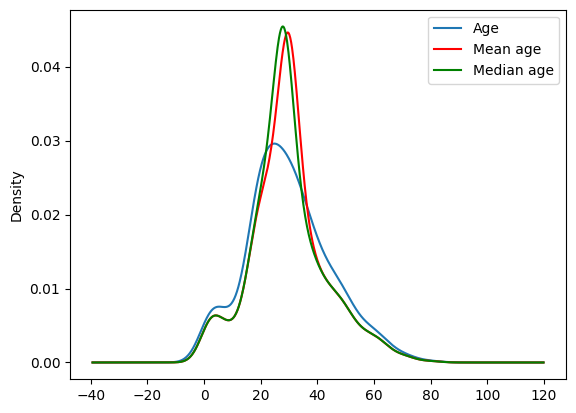

In [14]:
x_train['Age'].plot(kind='kde', label="Age")
x_train['age_mean'].plot(kind='kde', color='red', label='Mean age')
x_train['age_median'].plot(kind='kde', color='green', label='Median age')
plt.legend()

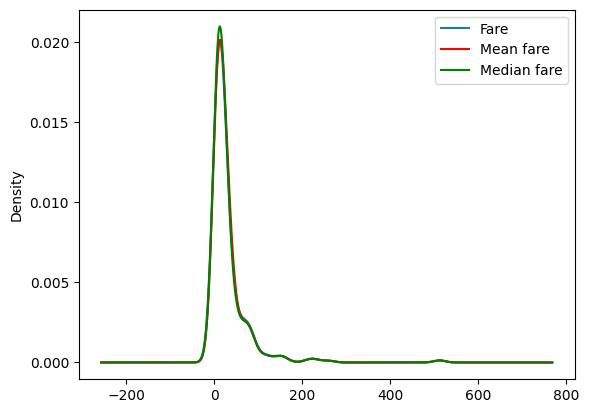

In [15]:
x_train['Fare'].plot(kind='kde', label="Fare")
x_train['fare_mean'].plot(kind='kde', color='red', label='Mean fare')
x_train['fare_median'].plot(kind='kde', color='green', label='Median fare')
plt.legend()

In [16]:
x_train.cov()

,Age,Fare,Family,age_mean,age_median,fare_mean,fare_median
Age,216.506980,72.599765,-6.773694,216.506980,216.506980,68.715853,66.422497
Fare,72.599765,2402.243424,13.877249,57.871315,61.330628,2402.243424,2402.243424
Family,-6.773694,13.877249,2.441329,-5.439915,-5.370222,13.233157,13.356232
age_mean,216.506980,57.871315,-5.439915,173.875507,173.875507,55.185305,53.343524
age_median,216.506980,61.330628,-5.370222,173.875507,174.405426,58.484058,56.578348
fare_mean,68.715853,2402.243424,13.233157,55.185305,58.484058,2290.746894,2290.746894
fare_median,66.422497,2402.243424,13.356232,53.343524,56.578348,2290.746894,2303.063353


In [17]:
x_train.corr()

,Age,Fare,Family,age_mean,age_median,fare_mean,fare_median
Age,1.000000,0.093609,-0.319493,1.000000,1.000000,0.091230,0.087907
Fare,0.093609,1.000000,0.178683,0.089295,0.094511,1.000000,1.000000
Family,-0.319493,0.178683,1.000000,-0.264034,-0.260255,0.176955,0.178122
age_mean,1.000000,0.089295,-0.264034,1.000000,0.998480,0.087441,0.084297
age_median,1.000000,0.094511,-0.260255,0.998480,1.000000,0.092527,0.089272
fare_mean,0.091230,1.000000,0.176955,0.087441,0.092527,1.000000,0.997322
fare_median,0.087907,1.000000,0.178122,0.084297,0.089272,0.997322,1.000000


<Axes: >

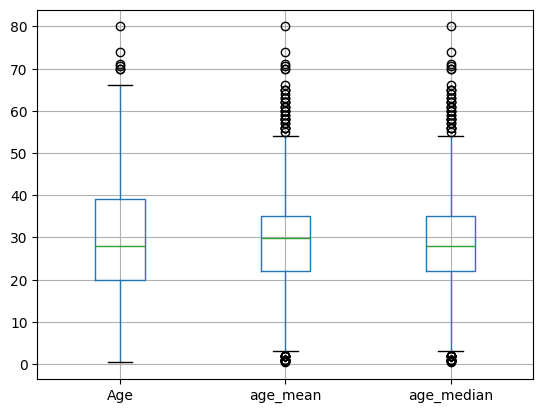

In [18]:
x_train[['Age','age_mean','age_median']].boxplot()

<Axes: >

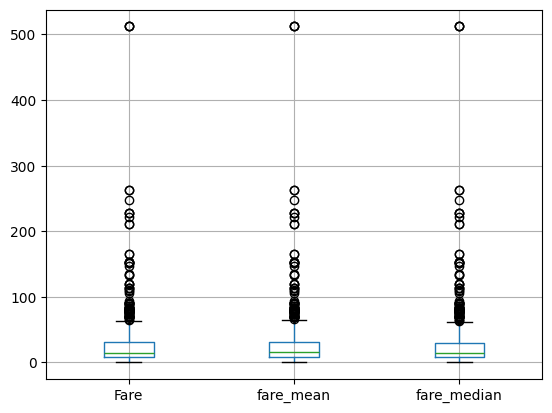

In [19]:
x_train[['Fare','fare_mean','fare_median']].boxplot()

### Using sklearn

In [63]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=5)

In [23]:
from sklearn.impute import SimpleImputer

In [24]:
imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')

In [25]:
from sklearn.compose import ColumnTransformer

In [29]:
trf = ColumnTransformer([
    ('imputer1', imputer1, ['Age']),
    ('imputer2', imputer2, ['Fare'])
], remainder='passthrough')

In [30]:
trf.fit(x_train)

,transformers,"[('imputer1', ...), ('imputer2', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [43]:
trf.named_transformers_['imputer1'].statistics_

array([28.])

In [45]:
trf.named_transformers_['imputer2'].statistics_

array([31.21688175])

In [47]:
x_train_trf = trf.transform(x_train)
x_test_trf = trf.transform(x_test)

In [49]:
x_train_trf

array([[19.    , 30.    ,  0.    ],
       [34.    , 32.5   ,  2.    ],
       [ 2.    , 12.2875,  1.    ],
       ...,
       [35.    , 26.2875,  0.    ],
       [32.    , 15.85  ,  1.    ],
       [31.    , 50.4958,  0.    ]], shape=(712, 3))

## Filling value with <b>Arbitrary value</b>(a single value)

In [51]:
df.sample(3)

,Age,Fare,Family,Survived
830,15.0,14.4542,1,1
276,45.0,7.7500,0,0
792,NaN,69.5500,10,0


In [56]:
x.sample(2)

,Age,Fare,Family
508,28.0,22.5250,0
192,19.0,7.8542,1


In [58]:
y.sample(2)

529    0
125    1
Name: Survived, dtype: int64

In [59]:
x_train.sample(2)

,Age,Fare,Family
494,21.0,8.0500,0
172,1.0,11.1333,2


In [64]:
x_train['age_99'] = x_train['Age'].fillna(99)
x_train['age_minus1'] = x_train['Age'].fillna(-1)

x_train['fare_999'] = x_train['Fare'].fillna(999)
x_train['fare_minus1'] = x_train['Fare'].fillna(-1)

In [65]:
x_train.sample(2)

,Age,Fare,Family,age_99,age_minus1,fare_999,fare_minus1
569,32.0,7.8542,0,32.0,32.0,7.8542,7.8542
637,31.0,26.2500,2,31.0,31.0,26.2500,26.2500


In [67]:
print("Variance of age column before imputation:", x_train['Age'].var())
print("Variance of age column after imputing 99:", x_train['age_99'].var())
print("Variance of age column after imputing -1:", x_train['age_minus1'].var())
print()
print("Variance of fare column before imputation:", x_train['Fare'].var())
print("Variance of fare column after imputing 999:", x_train['fare_999'].var())
print("Variance of fare column after imputing -1:", x_train['fare_minus1'].var())

Variance of age column before imputation: 217.29286946463318
Variance of age column after imputing 99: 952.0425033929081
Variance of age column after imputing -1: 330.68124610376196

Variance of fare column before imputation: 1788.8025768614632
Variance of fare column after imputing 999: 49079.191183341194
Variance of fare column after imputing -1: 1745.7107846307292
